In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm
rebuild_data=True

class DogsvsCats():
    img_size=50
    cats="PetImages/Cat"
    dogs="PetImages/Dog"
    labels = {cats:0, dogs:1}
    training_data = []
    catcount=0
    dogcount=0

    def make_training_data(self):
        for label in self.labels:
            print(label)
            for f in tqdm(os.listdir(label)):
                try:    
                    path = os.path.join(label,f)
                    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                    img = cv2.resize(img, (self.img_size, self.img_size))
                    self.training_data.append([np.array(img), np.eye(2)[self.labels[label]]])

                    if label ==self.cats:
                        self.catcount+=1
                    elif label == self.dogs:
                        self.dogcount+=1    
                except Exception as e:
                    pass
                    # print(str(e))
        np.random.shuffle(self.training_data)
        np.save("training_data.npy", np.array(self.training_data, dtype=object))
        print("cats: ", self.catcount)
        print("dogs: ", self.dogcount)

if rebuild_data:
    dogvcats = DogsvsCats()
    dogvcats.make_training_data()                                      

PetImages/Cat


100%|██████████| 12501/12501 [04:52<00:00, 42.77it/s]


PetImages/Dog


100%|██████████| 12501/12501 [02:27<00:00, 84.51it/s] 


cats:  12498
dogs:  12499


In [2]:
training_data = np.load("training_data.npy", allow_pickle=True)

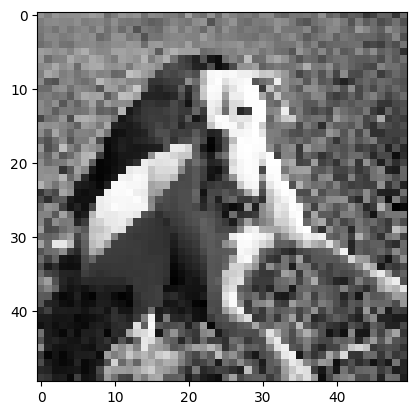

In [3]:
import matplotlib.pyplot as plt

plt.imshow(training_data[0][0], cmap="gray")
plt.show()

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 5)
        self.conv2 = nn.Conv2d(32, 64, 5)
        self.conv3 = nn.Conv2d(64, 128, 5)

        # Dummy forward to compute flatten size
        self._to_linear = None
        self.convs(torch.randn(1, 1, 50, 50))

        self.fc1 = nn.Linear(self._to_linear, 512)
        self.fc2 = nn.Linear(512, 2)

    def convs(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = F.max_pool2d(F.relu(self.conv3(x)), 2)
        if self._to_linear is None:
            self._to_linear = x[0].numel()
        return x

    def forward(self, x):
        x = self.convs(x)
        x = x.view(-1, self._to_linear)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)   # return raw logits (no softmax)
        return x

# Instantiate model on GPU if available
net = Net().to(device)
print(net)


Using device: cpu
Net(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=512, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Initialize optimizer with weight decay (L2 regularization)
optimizer = optim.Adam(net.parameters(), lr=0.0005, weight_decay=1e-5)
loss_function = nn.CrossEntropyLoss()

# Prepare tensors and move to GPU
X = torch.tensor([i[0] for i in training_data], dtype=torch.float32).view(-1, 1, 50, 50)
X = X / 255.0  # scale pixels to [0,1]
X = X.to(device)  # Move to GPU

# class indices instead of one-hot
y = torch.tensor([np.argmax(i[1]) for i in training_data], dtype=torch.long)
y = y.to(device)  # Move to GPU

# Train/validation split
VAL_PCT = 0.1
val_size = int(len(X) * VAL_PCT)

train_X = X[:-val_size]
train_y = y[:-val_size]

test_X = X[-val_size:]
test_y = y[-val_size:]

print(f"Training samples: {len(train_X)}, Test samples: {len(test_X)}")

Training samples: 22498, Test samples: 2499


In [15]:
BATCH_SIZE = 32  # Smaller batch size
EPOCHS = 20     # More epochs

# For plotting training progress
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):
    net.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i in tqdm(range(0, len(train_X), BATCH_SIZE)):
        batch_x = train_X[i:i+BATCH_SIZE].view(-1, 1, 50, 50)
        batch_y = train_y[i:i+BATCH_SIZE]
        
        optimizer.zero_grad()
        outputs = net(batch_x)
        loss = loss_function(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        running_loss += loss.item()
    
    # Calculate epoch statistics
    epoch_loss = running_loss / (len(train_X) / BATCH_SIZE)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f'Epoch: {epoch+1}/{EPOCHS}')
    print(f'Loss: {epoch_loss:.4f}')
    print(f'Training Accuracy: {epoch_acc:.2f}%')

  0%|          | 0/704 [00:00<?, ?it/s]

  0%|          | 0/704 [00:00<?, ?it/s]

100%|██████████| 704/704 [00:44<00:00, 15.74it/s]


  0%|          | 0/704 [00:00<?, ?it/s]

100%|██████████| 704/704 [00:44<00:00, 15.74it/s]


...

Epoch: 18/20
Loss: 0.1278
Training Accuracy: 94.92%


100%|██████████| 704/704 [00:42<00:00, 16.69it/s]


Epoch: 19/20
Loss: 0.1166
Training Accuracy: 95.24%


100%|██████████| 704/704 [00:41<00:00, 16.99it/s]

Epoch: 20/20
Loss: 0.1086
Training Accuracy: 95.82%


In [17]:
# Evaluation
net.eval()  # Set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():
    for i in tqdm(range(0, len(test_X), BATCH_SIZE)):
        batch_x = test_X[i:i+BATCH_SIZE].view(-1, 1, 50, 50)
        batch_y = test_y[i:i+BATCH_SIZE]
        
        outputs = net(batch_x)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')
print(f'Training Accuracy: {epoch_acc:.2f}%')

100%|██████████| 79/79 [00:01<00:00, 44.45it/s]

100%|██████████| 79/79 [00:01<00:00, 44.45it/s]

Test Accuracy: 74.71%
Training Accuracy: 95.82%
